# Machine Translation Project: Russian to English (Biomedical Domain)

This Jupyter Notebook serves as an **organized workflow** for training and evaluating a **Neural Machine Translation (NMT) model** using **Sequence-to-Sequence with Attention**.

In [ ]:
# Clone repo from github
#!git clone https://fboglind@github.com/fboglind/lab4_mt_project.git

In [ ]:
# Install dependencies (if not installed)
#!pip install torch pandas matplotlib seaborn sentencepiece sacrebleu

## **1. Create parallel corpus and test set**
- Reads files containing abstracts
- Creates a parallel corpus
- Creates a test set

In [9]:
# Creating parallel corpus and test set
!mkdir -p data
!python3 scripts/preprocess_wmt22.py

Traceback (most recent call last):
  File "/home/fredrik/Desktop/Applied Programming/lab4b/scripts/preprocess_wmt22.py", line 40, in <module>
    out_f.write(f"{texts['ru']}\t{texts['en']}\n")  # Switched order
KeyError: 'ru'


## **2. Load & Explore Data**


- Load the parallel corpus
- Analyze text length distributions
- Check for alignment issues
- Clean the data

       Russian English
count        0       0
unique       0       0
top        NaN     NaN
freq       NaN     NaN
Empty DataFrame
Columns: [Russian, English]
Index: []


/tmp/ipykernel_205821/4146461951.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


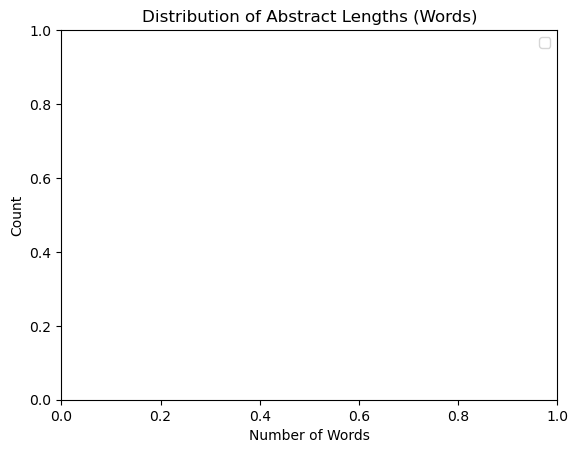

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("data/parallel_corpus.tsv", sep="\t", encoding="utf-8")

# Basic statistics
print(df.describe())
print(df.head())

# Plot text length distributions
df["Russian_Length"] = df["Russian"].apply(lambda x: len(x.split()))
df["English_Length"] = df["English"].apply(lambda x: len(x.split()))

sns.histplot(df["Russian_Length"], bins=30, kde=True, label="Russian", color="blue")
sns.histplot(df["English_Length"], bins=30, kde=True, label="English", color="orange", alpha=0.6)
plt.legend()
plt.title("Distribution of Abstract Lengths (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Count")
plt.show()

Let's remove some of the 'misaligned' abstracts

In [2]:
!python3 scripts/clean_parallel_corpus.py --input data/parallel_corpus.tsv --output data/cleaned_parallel_corpus.tsv

Cleaned parallel corpus saved to data/cleaned_parallel_corpus.tsv


In [3]:
# Check the cleaned data
!head data/cleaned_parallel_corpus.tsv

Russian	English	Russian_Length	English_Length	Length_Ratio
Резюме Цель: Определить, в какой степени грипп способствует заражению лиц всех возрастов в Бангладеш тяжелой острой респираторной инфекцией (ТОРИ), которая является основной причиной детской смертности. Методы: Врачами были взяты мазки из носа и зева для анализа на вирус гриппа у пациентов, которые были госпитализированы в течение семи дней от начала заболевания тяжелой острой респираторной инфекцией (ТОРИ) или консультировались у врача в амбулаторном режиме по поводу гриппоподобной болезни (ГПБ). Было проведено исследование пользования медико-санитарной помощью на уровне общин для определения доли жителей участка, обслуживаемого больницей, которые обращались за помощью в обследуемые медицинские учреждения, и расчета заболеваемости гриппом с использованием указанного показателя в качестве знаменателя. Результаты: Оценочные показатели заболеваемости ТОРИ, коррелируемой с гриппом, у детей в возрасте до 5 лет, составили 6,7 (95% д

In [4]:
# Check tail also, just to be sure
!tail data/cleaned_parallel_corpus.tsv

Представлен обзор современных публикаций, посвященных функциональной магнитно-резонансной томографии (фМРТ), рассмотрены практические аспекты ее применения в нейрохирургии. Отмечены преимущества и недостатки методов, приведены результаты хирургического лечения пациентов с использованием функциональной нейронавигации. Отдельное внимание уделено оценке точности фМРТ, новому методу бесстимуляционной нейровизуализации. Приведены рекомендации применения фМРТ в нейроонкологии и хирургии артериовенозных мальформаций.	The study is a short review of articles concerning functional magnetic resonance imaging (fMRI) and its practical application in neurosurgery. Advantages and disadvantages of the methods are considered, the results of surgical treatment of patients using functional navigation are presented. Separate attention is paid to fMRI precision, a new resting-state method of visualization. Practical advices of fMRI application in neurooncology and surgery of arteriovenous malformations are

Some of the abstracts are quite long, we should split them into sentences before further tokenization.

In [5]:
!python3 scripts/split_abstracts.py --input data/cleaned_parallel_corpus.tsv --output data/sentence_aligned_corpus.tsv

Sentence-aligned corpus saved to data/sentence_aligned_corpus.tsv


We extract only the russian part of the corpus

In [ ]:
!python3 extract_russian.py --input data/sentence_aligned_corpus.tsv --output data/russian_only.txt

In [ ]:
!head -n5 data/russian_only.txt

## **3. Preprocessing: SentencePiece Tokenization**

- Extract source language data
- Train a SentencePiece model
- Tokenize the training and test sets

In [ ]:
import sentencepiece as spm

# Train SentencePiece. Output: spm_ru_only.model, spm_ru_only.vocab
!python3 scripts/sentencepiece_train.py

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/sentence_aligned_corpus.tsv
  input_format: 
  model_prefix: models/spm_ru_only
  model_type: UNIGRAM
  vocab_size: 30000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_

In [8]:
!head -n20 models/spm_ru_only.vocab

<unk>	0
<s>	0
</s>	0
.	-3.41421
,	-3.45515
▁of	-3.64252
▁the	-3.70122
▁	-3.96762
▁and	-4.28776
▁и	-4.42452
▁in	-4.45951
▁(	-4.546
-	-4.57877
▁в	-4.66162
▁с	-4.98433
)	-5.04963
▁with	-5.08484
▁to	-5.09301
ой	-5.14951
s	-5.19055


In [18]:
# Apply SentencePiece Tokenization
!python3 scripts/apply_sentencepiece.py --input data/sentence_aligned_corpus.tsv --output data/spm_parallel_corpus.tsv --model models/spm_ru_only.model

SentencePiece tokenization complete. Processed 83620 sentences. Saved to data/spm_parallel_corpus.tsv


In [19]:
!head -n 5 data/spm_parallel_corpus.tsv

Russian	English
▁Резюме ▁Цель : ▁Определить , ▁в ▁как ой ▁степени ▁грипп ▁способству ет ▁за р ажен ию ▁лиц ▁всех ▁возраст ов ▁в ▁Бангладеш ▁тяжелой ▁острой ▁респираторн ой ▁инфекцией ▁( ТО РИ ), ▁которая ▁является ▁основной ▁причиной ▁детск ой ▁смертности .	To determine how much influenza contributes to severe acute respiratory illness (SARI), a leading cause of death in children, among people of all ages in Bangladesh.
▁Методы : ▁В ра ч ами ▁были ▁взяты ▁ма з ки ▁из ▁носа ▁и ▁ з ева ▁для ▁анализа ▁на ▁вирус ▁гриппа ▁у ▁пациентов , ▁которые ▁были ▁госпитализирова ны ▁в ▁течение ▁семи ▁дней ▁от ▁начала ▁заболевания ▁тяжелой ▁острой ▁респираторн ой ▁инфекцией ▁( ТО РИ ) ▁или ▁консультирова лись ▁у ▁врача ▁в ▁амбулаторном ▁режиме ▁по ▁по воду ▁грипп оподобн ой ▁болезни ▁( ГП Б ).	Physicians obtained nasal and throat swabs to test for influenza virus from patients who were hospitalized within 7 days of the onset of severe acute respiratory infection (SARI) or who consulted as outpatients f

We must also tokenize the test set

In [22]:
!python3 scripts/apply_sentencepiece.py --input data/test_raw_ru.txt --output data/spm_test_set.tsv --model models/spm_ru_only.model --is_test_set

SentencePiece tokenization complete. Processed 50 TEST sentences. Saved to data/spm_test_set.tsv


In [23]:
!head -n 5 data/spm_test_set.tsv

▁Реализаци я ▁эффективной ▁межсекторальн ой ▁политики ▁в ▁области ▁питания ▁остается ▁сложной ▁задачей , ▁актуальной ▁во ▁всем ▁мире . ▁Изуч ая ▁отчет ы ▁с овещани й ▁и ▁консультаци й ▁Всемирн ой ▁организации ▁здравоохранения ▁( ВОЗ ), ▁с оз ы ва емых ▁для ▁политическ ого ▁руководства ▁государств - член ов ▁региона ▁западн ой ▁части ▁Т их ого ▁океана , ▁авторы ▁сообщили ▁о ▁том , ▁как ▁лица , ▁определяющи е ▁национальн ую ▁политику , ▁а ▁также ▁внешни е ▁субъект ы ▁могут ▁поддерживать ▁различны е ▁уровни ▁реализации ▁политики ▁в ▁области ▁питания . ▁Ключев ые ▁выводы ▁политическ ого ▁руководства , ▁участвующе го ▁в ▁с овещани я х ▁по ▁вопросам ▁про дов оль ст в ия ▁и ▁питания , ▁включают ▁в ▁себя ▁то , ▁что ▁реализаци я ▁политики ▁в ▁области ▁питания ▁на ▁уровне ▁стран ▁опира ется ▁на ▁четк ую ▁разработку ▁политики , ▁организационно е ▁планирование ▁и ▁механизмы ▁управления , ▁которые ▁способству ют ▁коллективно й ▁ответственности ▁во ▁многих ▁сектора х . ▁По ли тические ▁де я тели , ▁

## **4. Model Training**

- Train the sequence-to-sequence model
- Use label smoothing to improve training stability
- Save the trained model

In [24]:
# Train the model
!python3 scripts/seq2seq_train.py

Loading training data from data/spm_parallel_corpus.tsv...
Loaded 83620 samples after dropping NaN values
Building vocabularies...
Vocabulary sizes: Source = 21142, Target = 118678
Training on: cpu
Starting training for 15 epochs...
^C


## **5. Translation & Evaluation**

- Translate test data
- Evaluate performance using BLEU and chrF

In [ ]:
# Translate test set
!python3 scripts/translate_wmt_test.py

In [ ]:
# Evaluate translations
!python3 scripts/evaluate_translations.py --hyp data/wmt_test_translations_with_beam.txt --ref data/test_reference_en.txt
print("Project setup complete! Ready for further analysis.")

## **6. Next Steps & Improvements**

- Compare GRU vs. LSTM architectures
- Improve handling of long sequences (segmenting abstracts)
- Fine-tune hyperparameters for better results